In [1]:
import os
os.getcwd()


'/drive/notebooks/AIproject'

In [2]:
import micropip
await micropip.install("pandas")

In [3]:
import micropip
await micropip.install("seaborn")

In [4]:
import micropip
await micropip.install("imbalanced-learn")

In [5]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
df = pd.read_csv("Breast_Cancer.csv")

# Strip whitespace from column names and string values
df.columns = df.columns.str.strip()
df["Grade"]          = df["Grade"].astype(str).str.strip().replace("anaplastic; Grade IV", "4")
df["Marital Status"] = df["Marital Status"].astype(str).str.strip()

print(f"Shape : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Target classes: {df['Status'].unique().tolist()}")
df.head()

Shape : 4024 rows x 16 columns
Target classes: ['Alive', 'Dead']


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [9]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

Status
Alive    3408
Dead      616
Name: count, dtype: int64

Imbalance ratio: 5.5:1


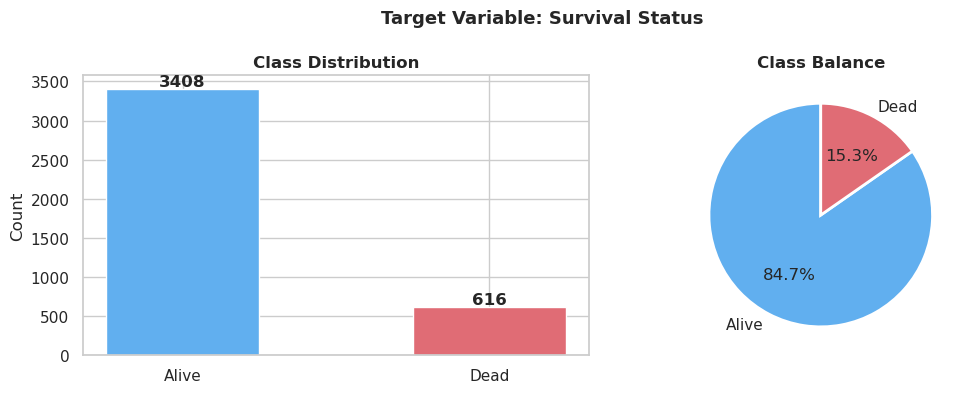

In [10]:
class_counts = df["Status"].value_counts()
print(class_counts)
print(f"\nImbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(class_counts.index, class_counts.values,
            color=["#61AFEF","#E06C75"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=["#61AFEF","#E06C75"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class Balance", fontweight="bold")

plt.suptitle("Target Variable: Survival Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

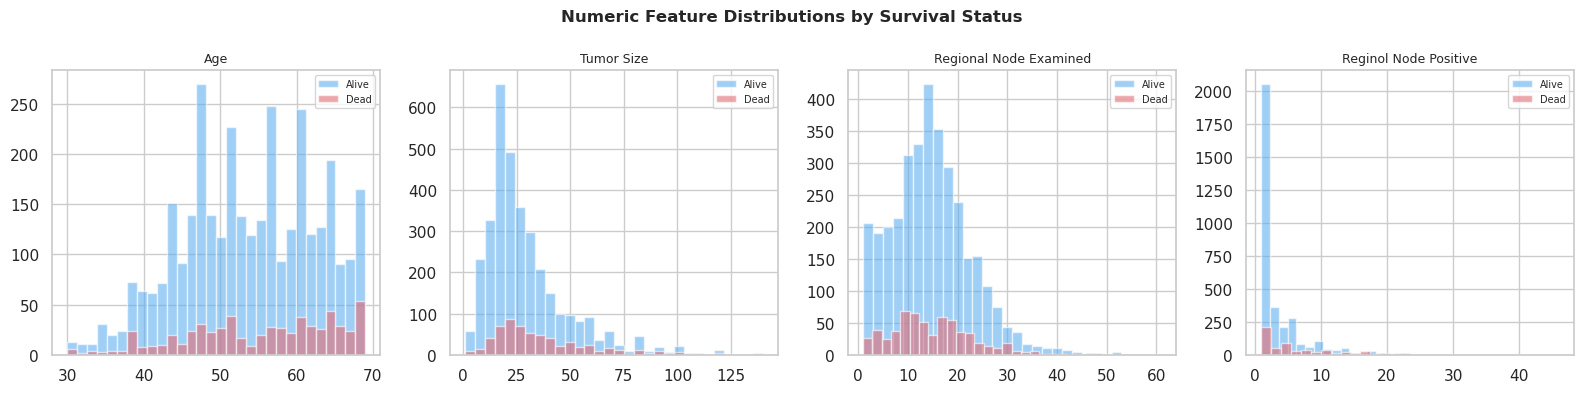

In [11]:
numeric_cols = ["Age", "Tumor Size", "Regional Node Examined", "Reginol Node Positive"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    for status, color in zip(["Alive", "Dead"], ["#61AFEF", "#E06C75"]):
        ax.hist(df[df["Status"] == status][col], bins=30,
                alpha=0.6, label=status, color=color, edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Numeric Feature Distributions by Survival Status", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

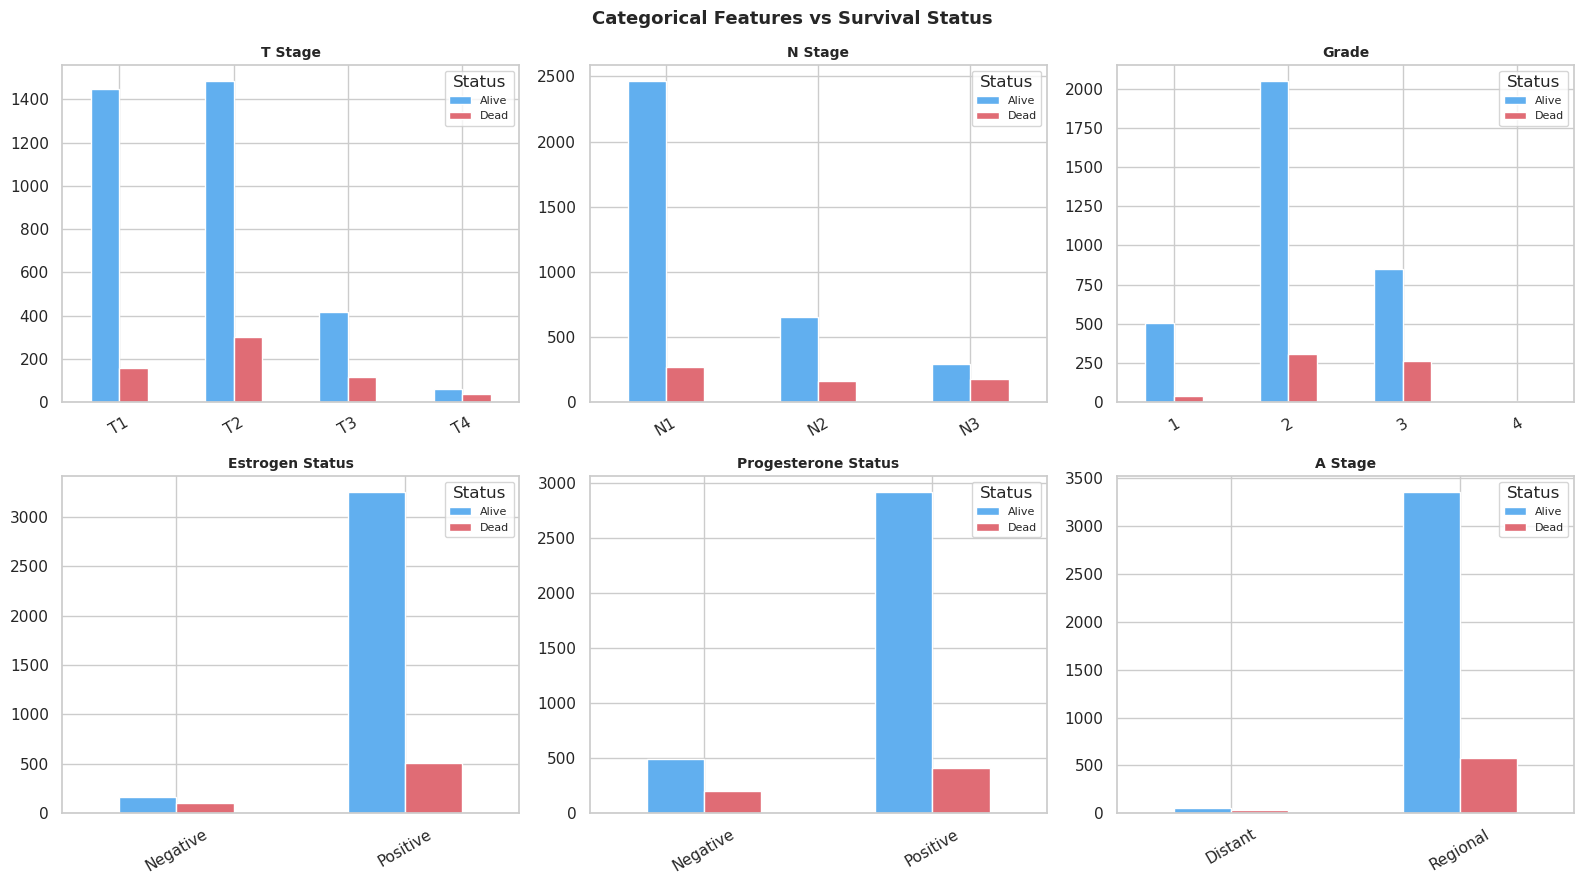

In [12]:
cat_plot_cols = ["T Stage", "N Stage", "Grade", "Estrogen Status",
                 "Progesterone Status", "A Stage"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_plot_cols):
    ct = df.groupby([col, "Status"]).size().unstack(fill_value=0)
    ct.plot(kind="bar", ax=ax, color=["#61AFEF","#E06C75"],
            edgecolor="white", rot=30)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(title="Status", fontsize=8)

plt.suptitle("Categorical Features vs Survival Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

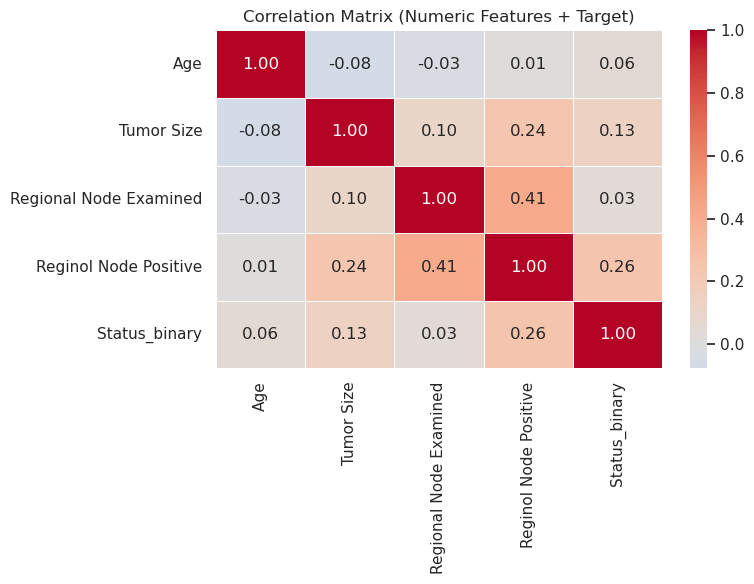

In [13]:
numeric_df = df[["Age","Tumor Size","Regional Node Examined","Reginol Node Positive"]].copy()
numeric_df["Status_binary"] = (df["Status"] == "Dead").astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix (Numeric Features + Target)", fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# Step 1: drop leaky column
df_model = df.drop(columns=["Survival Months"]).copy()

# Step 2: one-hot encode all nominal categorical features
cat_cols = ["Race", "Marital Status", "T Stage", "N Stage", "6th Stage",
            "differentiate", "Grade", "A Stage", "Estrogen Status", "Progesterone Status"]

df_enc = pd.get_dummies(df_model, columns=cat_cols, drop_first=False)

# Convert bool dummies to int (0/1)
bool_cols = df_enc.select_dtypes(include="bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

# Encode target: Dead=1, Alive=0
df_enc["Status"] = (df_enc["Status"] == "Dead").astype(int)

print(f"Features after encoding : {df_enc.shape[1] - 1}")
print(f"Original shape          : {df.shape[1] - 1} features")
print(f"Encoded column sample   : {df_enc.columns.tolist()[:8]}")

# Save encoded dataset
df_enc.to_csv("New_Breast_Cancer.csv", index=False)

print("\nSaved → New_Breast_Cancer.csv")

Features after encoding : 38
Original shape          : 15 features
Encoded column sample   : ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive', 'Status', 'Race_Black', 'Race_Other', 'Race_White']

Saved → New_Breast_Cancer.csv


In [22]:
df = pd.read_csv("New_Breast_Cancer.csv")
X = df_enc.drop(columns=["Status"]).astype(float)
y = df_enc["Status"].values
feature_columns = X.columns.tolist()

# Stratified split preserves class proportions
# Note: Keep data in original (unscaled) form - scaling will be done inside Pipeline
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"Train class distribution (Alive / Dead) : {np.bincount(y_train)}")
print(f"Test class distribution  (Alive / Dead) : {np.bincount(y_test)}")

Train shape : (3219, 38)
Test shape  : (805, 38)
Train class distribution (Alive / Dead) : [2726  493]
Test class distribution  (Alive / Dead) : [682 123]


In [30]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", KNeighborsClassifier())
    ])
}
predictions   = {}
probabilities = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name]    = model.predict(X_test)
    probabilities[name]  = model.predict_proba(X_test)[:, 1]

print("Baseline models trained with Pipeline (scaling fit only on training data).")

Baseline models trained with Pipeline (scaling fit only on training data).


In [34]:

# --- Logistic Regression ---
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Pipeline: Scaler → SMOTE → Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

predictions["Logistic Regression (Tuned)"] = best_lr.predict(X_test)

probabilities["Logistic Regression (Tuned)"] = (
    best_lr.predict_proba(X_test)[:, 1]
)

trained_models["Logistic Regression (Tuned)"] = best_lr

print("Best LR params  :", lr_grid.best_params_)
print("Best CV F1-macro:", round(lr_grid.best_score_, 4))

Best LR params  : {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1-macro: 0.6106


In [35]:
# --- Random Forest ---
# Pipeline ensures scaler is fit only on each fold's training data
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

predictions["Random Forest (Tuned)"] = best_rf.predict(X_test)

probabilities["Random Forest (Tuned)"] = best_rf.predict_proba(X_test)[:, 1]

trained_models["Random Forest (Tuned)"] = best_rf

print("Best RF params  :", rf_grid.best_params_)
print("Best CV F1-macro:", round(rf_grid.best_score_, 4))

Best RF params  : {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV F1-macro: 0.6154


In [36]:

# --- KNN ---
# Pipeline ensures scaler is fit only on each fold's training data
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_

predictions["KNN (Tuned)"] = best_knn.predict(X_test)

probabilities["KNN (Tuned)"] = best_knn.predict_proba(X_test)[:, 1]

trained_models["KNN (Tuned)"] = best_knn

print("Best KNN params  :", knn_grid.best_params_)
print("Best CV F1-macro :", round(knn_grid.best_score_, 4))

Best KNN params  : {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}
Best CV F1-macro : 0.5701


In [42]:
metrics_rows = []

for model_name, y_pred in predictions.items():
    row = {
        "Model": model_name,

        # Overall metrics
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, probabilities[model_name]),

        # Macro metrics
        "Precision-Macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall-Macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),

        # Minority class (Dead = 1)
        "Precision-Dead": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Recall-Dead": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "F1-Dead": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    }

    metrics_rows.append(row)

comparison_df = (
    pd.DataFrame(metrics_rows)
    .sort_values("F1-Dead", ascending=False)
    .reset_index(drop=True)
)

# Show clean table
print(comparison_df.round(4).to_string(index=False))

                      Model  Accuracy  ROC-AUC  Precision-Macro  Recall-Macro  F1-Macro  Precision-Dead  Recall-Dead  F1-Dead
        Logistic Regression    0.6857   0.7258           0.5978        0.6746    0.5893          0.2774       0.6585   0.3904
Logistic Regression (Tuned)    0.6882   0.7275           0.5973        0.6727    0.5900          0.2778       0.6504   0.3893
                KNN (Tuned)    0.7006   0.6627           0.5739        0.6201    0.5731          0.2562       0.5041   0.3397
                        KNN    0.6683   0.6410           0.5640        0.6110    0.5537          0.2372       0.5285   0.3275
              Random Forest    0.8373   0.6853           0.6380        0.5574    0.5670          0.4130       0.1545   0.2249
      Random Forest (Tuned)    0.8286   0.6902           0.6101        0.5523    0.5598          0.3585       0.1545   0.2159


In [45]:
for model_name in predictions.keys():
    print("=" * 70)
    print(f"Classification Report: {model_name}")

    report = classification_report(
        y_test,
        predictions[model_name],
        target_names=["Alive", "Dead"],
        zero_division=0
    )

    print(report)

Classification Report: Logistic Regression
              precision    recall  f1-score   support

       Alive       0.92      0.69      0.79       682
        Dead       0.28      0.66      0.39       123

    accuracy                           0.69       805
   macro avg       0.60      0.67      0.59       805
weighted avg       0.82      0.69      0.73       805

Classification Report: Random Forest
              precision    recall  f1-score   support

       Alive       0.86      0.96      0.91       682
        Dead       0.41      0.15      0.22       123

    accuracy                           0.84       805
   macro avg       0.64      0.56      0.57       805
weighted avg       0.79      0.84      0.80       805

Classification Report: KNN
              precision    recall  f1-score   support

       Alive       0.89      0.69      0.78       682
        Dead       0.24      0.53      0.33       123

    accuracy                           0.67       805
   macro avg       0.

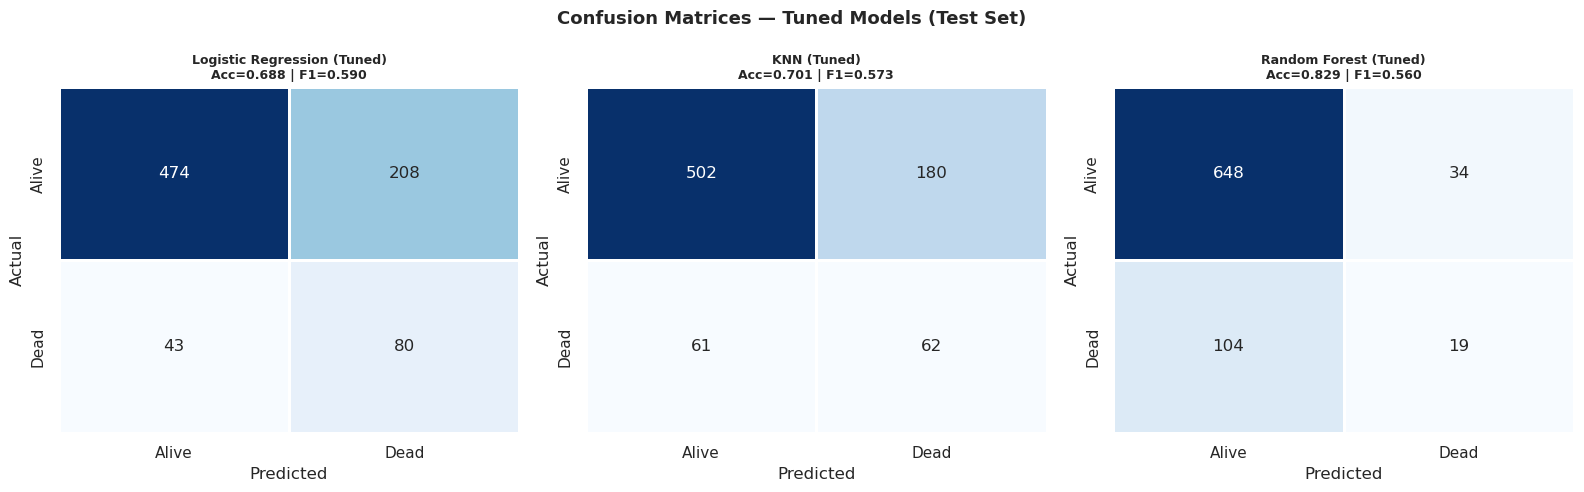

In [47]:
tuned_models = [m for m in comparison_df["Model"] if "Tuned" in m]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
CLASS_NAMES = ["Alive", "Dead"]
for ax, model_name in zip(axes, tuned_models):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                linewidths=1, linecolor="white")
    acc = accuracy_score(y_test, predictions[model_name])
    f1  = f1_score(y_test, predictions[model_name], average="macro", zero_division=0)
    ax.set_title(f"{model_name}\nAcc={acc:.3f} | F1={f1:.3f}",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Tuned Models (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

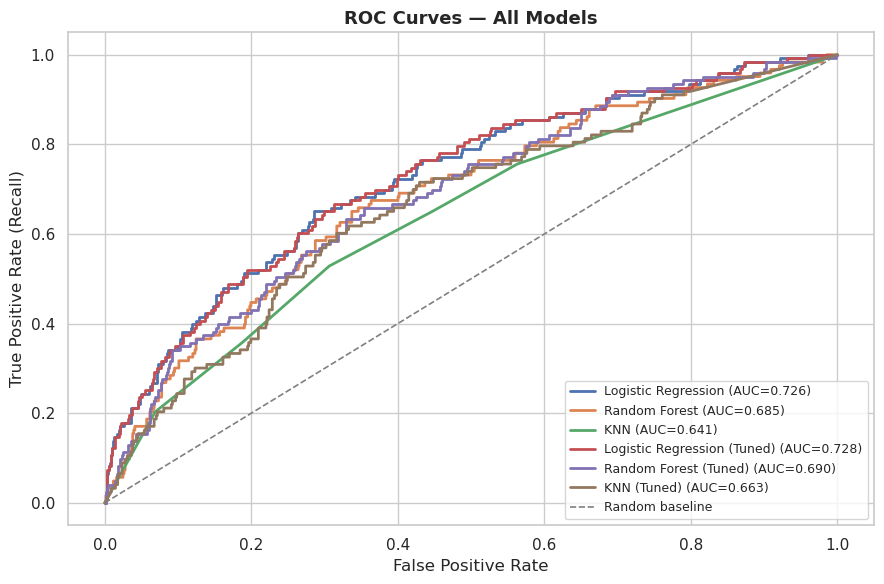

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, probs in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    model_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f"{model_name} (AUC={model_auc:.3f})", linewidth=2)

ax.plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1.2, label="Random baseline")

ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [54]:
best_model_name = comparison_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_row = comparison_df.iloc[0]
comparison_df = comparison_df.sort_values("F1-Dead", ascending=False)
print(f"Selected model : {best_model_name}")
print(f"F1-Dead        : {best_row['F1-Dead']:.4f}")
print(f"ROC-AUC        : {best_row['ROC-AUC']:.4f}")
print(f"Recall-Dead    : {best_row['Recall-Dead']:.4f}")
print()

print(
    "Reason: Selected based on highest F1-Dead score, "
    "ensuring optimal balance between precision and recall for the critical class (Dead), "
    "with strong ROC-AUC indicating robust overall discrimination performance."
)

Selected model : Logistic Regression
F1-Dead        : 0.3904
ROC-AUC        : 0.7258
Recall-Dead    : 0.6585

Reason: Selected based on highest F1-Dead score, ensuring optimal balance between precision and recall for the critical class (Dead), with strong ROC-AUC indicating robust overall discrimination performance.


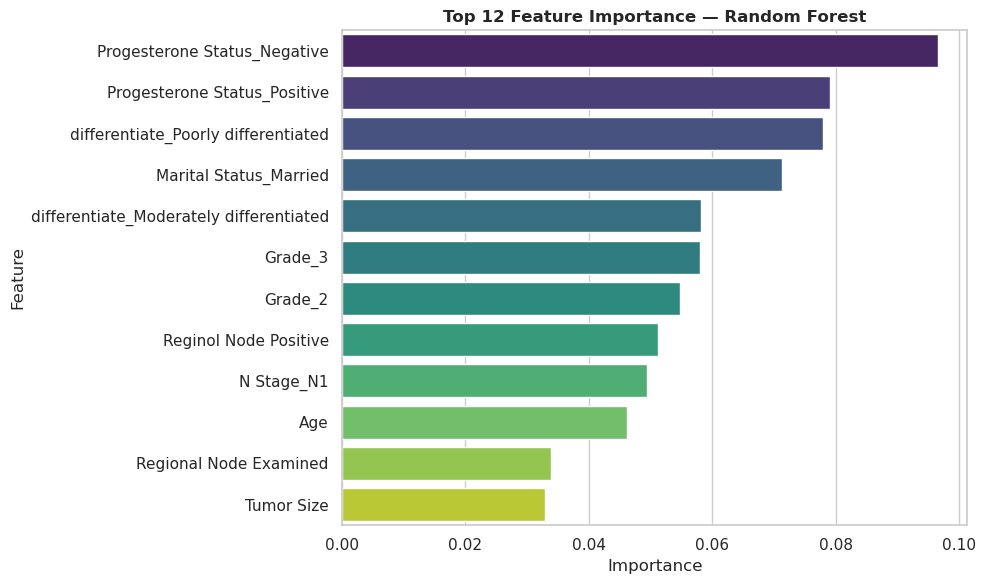

In [62]:


rf_model = trained_models.get("Random Forest (Tuned)") or trained_models.get("Random Forest (Baseline)")
rf_model = rf_model.named_steps["model"]  # 👈 IMPORTANT FIX
imp_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(12)

plt.figure(figsize=(10,6))

sns.barplot(
    data=imp_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 12 Feature Importance — Random Forest", fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

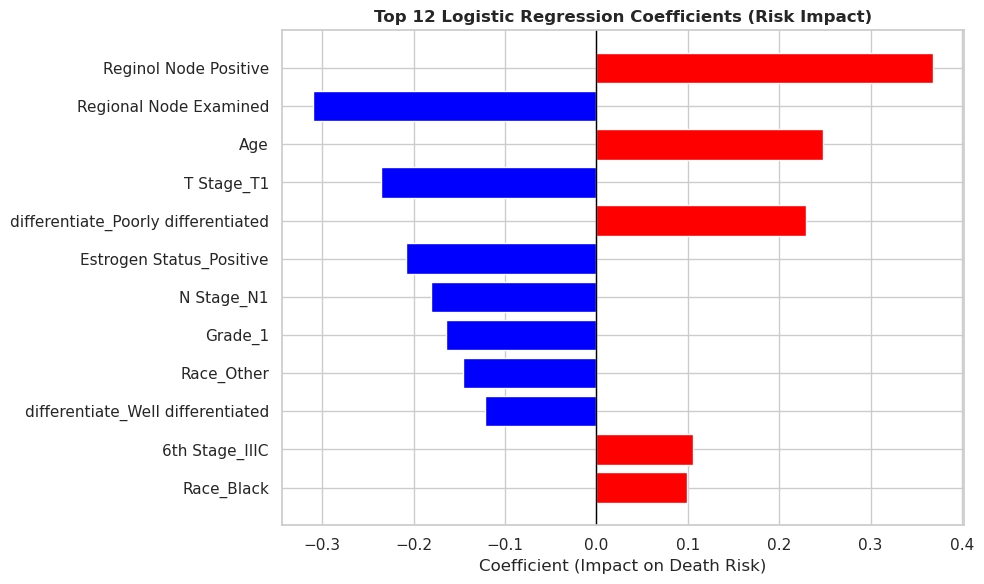

In [63]:
lr_model = trained_models.get("Logistic Regression (Tuned)") or trained_models.get("Logistic Regression")
log_reg = lr_model.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": log_reg.coef_[0]
})

# Top 12 by absolute impact
coef_df = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index).head(12)

# Colors: red = increases death risk, blue = decreases risk
colors = ["red" if c > 0 else "blue" for c in coef_df["Coefficient"]]

plt.figure(figsize=(10,6))

plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("Top 12 Logistic Regression Coefficients (Risk Impact)", fontweight="bold")
plt.xlabel("Coefficient (Impact on Death Risk)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [64]:
# --- Define new patient ---
new_patient_raw = pd.DataFrame([{
    "Age": 52,
    "Race": "White",
    "Marital Status": "Married",
    "T Stage": "T2",
    "N Stage": "N1",
    "6th Stage": "IIA",
    "differentiate": "Moderately differentiated",
    "Grade": "2",
    "A Stage": "Regional",
    "Tumor Size": 28,
    "Estrogen Status": "Positive",
    "Progesterone Status": "Positive",
    "Regional Node Examined": 12,
    "Reginol Node Positive": 2
}])

# --- Combine for encoding ---
df_base = df_model.drop(columns=["Status"]).copy()
combined = pd.concat([df_base, new_patient_raw], ignore_index=True)

# --- One-hot encoding ---
combined_enc = pd.get_dummies(combined, columns=cat_cols, drop_first=False)

# Convert bools
bool_cols = combined_enc.select_dtypes(include="bool").columns
combined_enc[bool_cols] = combined_enc[bool_cols].astype(int)

# --- Extract new patient ---
new_patient_enc = combined_enc.iloc[[-1]].reindex(columns=feature_columns, fill_value=0)

# --- IMPORTANT: NO SCALER MANUAL STEP ---
pred_label = best_model.predict(new_patient_enc)[0]
pred_proba = best_model.predict_proba(new_patient_enc)[0]

# --- Print results ---
print("=" * 50)
print("New Patient Clinical Profile:")
print("=" * 50)

for col, val in new_patient_raw.iloc[0].items():
    print(f"{col:<30}: {val}")

print("=" * 50)
print(f"Predicted class : {'Dead' if pred_label == 1 else 'Alive'}")
print(f"P(Alive) = {pred_proba[0]:.4f} | P(Dead) = {pred_proba[1]:.4f}")

New Patient Clinical Profile:
Age                           : 52
Race                          : White
Marital Status                : Married
T Stage                       : T2
N Stage                       : N1
6th Stage                     : IIA
differentiate                 : Moderately differentiated
Grade                         : 2
A Stage                       : Regional
Tumor Size                    : 28
Estrogen Status               : Positive
Progesterone Status           : Positive
Regional Node Examined        : 12
Reginol Node Positive         : 2
Predicted class : Alive
P(Alive) = 0.6313 | P(Dead) = 0.3687
